# 학생 성취도 예측 모델
### 코딩 교육 현장 경험 기반 - 위험군 학생 조기 발견 분류 모델

**분석 목표**: 학생의 학습 패턴 데이터를 활용하여 최종 성취도 저하를 사전에 예측하고, 교육 현장에서 적용 가능한 인사이트 도출

## 0. 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [2]:
# UCI Student Performance 데이터 로드
# 다운로드: https://archive.ics.uci.edu/dataset/320/student+performance
# data/ 폴더에 student-mat.csv 저장 후 실행

df = pd.read_csv('../data/student-mat.csv', sep=';')
print(f'데이터 크기: {df.shape}')
df.head()

데이터 크기: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 1. 데이터 탐색 (EDA)

In [3]:
# 기본 정보 확인
print('=== 데이터 기본 정보 ===')
print(f'행: {df.shape[0]}, 열: {df.shape[1]}')
print(f'\n결측치:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print(f'\n최종 성적(G3) 분포:')
print(df['G3'].describe())

=== 데이터 기본 정보 ===
행: 395, 열: 33

결측치:
Series([], dtype: int64)

최종 성적(G3) 분포:
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


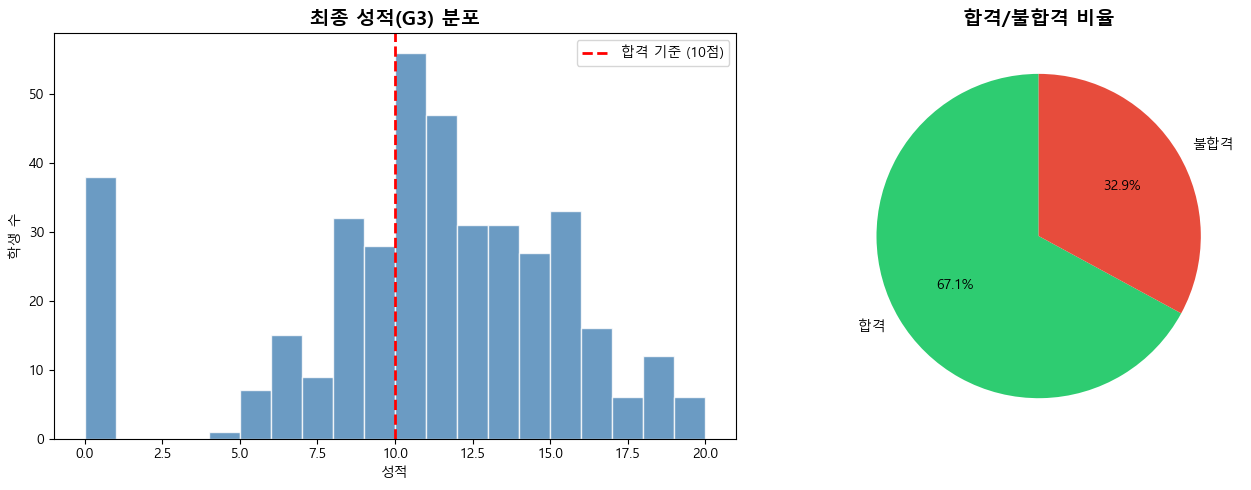

합격: 265명 (67.1%), 불합격: 130명 (32.9%)


In [4]:
# 최종 성적 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 성적 히스토그램
axes[0].hist(df['G3'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=10, color='red', linestyle='--', linewidth=2, label='합격 기준 (10점)')
axes[0].set_title('최종 성적(G3) 분포', fontsize=14, fontweight='bold')
axes[0].set_xlabel('성적')
axes[0].set_ylabel('학생 수')
axes[0].legend()

# 합격/불합격 비율
df['pass'] = (df['G3'] >= 10).astype(int)
pass_counts = df['pass'].value_counts()
axes[1].pie(pass_counts, labels=['합격', '불합격'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('합격/불합격 비율', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/grade_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'합격: {pass_counts[1]}명 ({pass_counts[1]/len(df)*100:.1f}%), 불합격: {pass_counts[0]}명 ({pass_counts[0]/len(df)*100:.1f}%)')

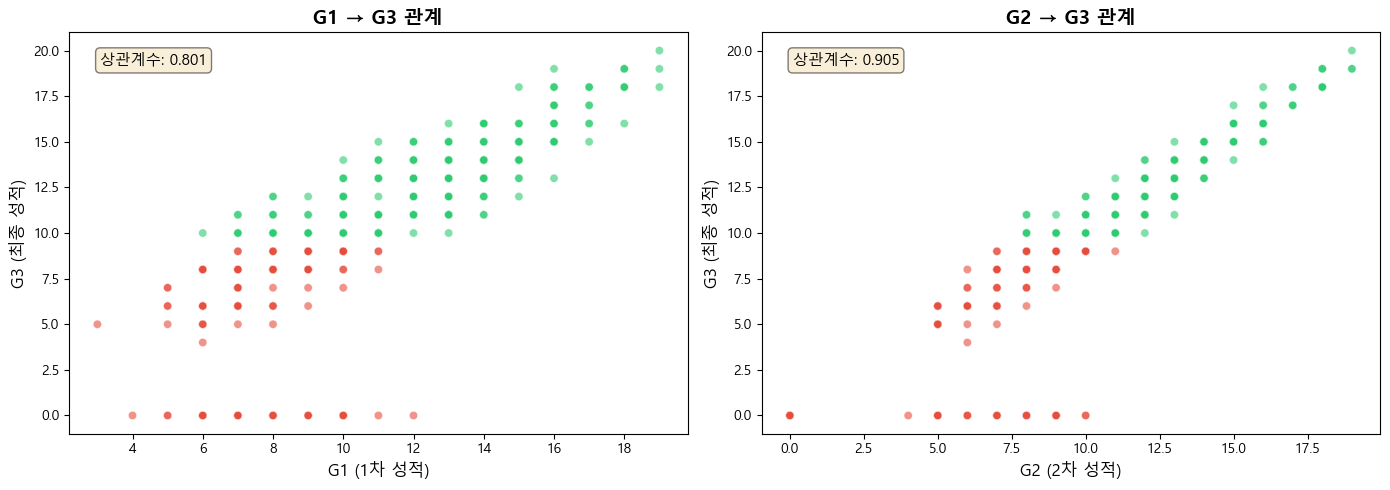

In [5]:
# 이전 성적 vs 최종 성적 관계
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, grade in enumerate(['G1', 'G2']):
    axes[i].scatter(df[grade], df['G3'],
                    c=df['pass'].map({1: '#2ecc71', 0: '#e74c3c'}),
                    alpha=0.6, edgecolors='white', linewidth=0.5)
    axes[i].set_xlabel(f'{grade} (1차 성적)' if grade == 'G1' else f'{grade} (2차 성적)', fontsize=12)
    axes[i].set_ylabel('G3 (최종 성적)', fontsize=12)
    axes[i].set_title(f'{grade} → G3 관계', fontsize=14, fontweight='bold')
    corr = df[grade].corr(df['G3'])
    axes[i].text(0.05, 0.95, f'상관계수: {corr:.3f}', transform=axes[i].transAxes,
                 fontsize=11, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../data/grade_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

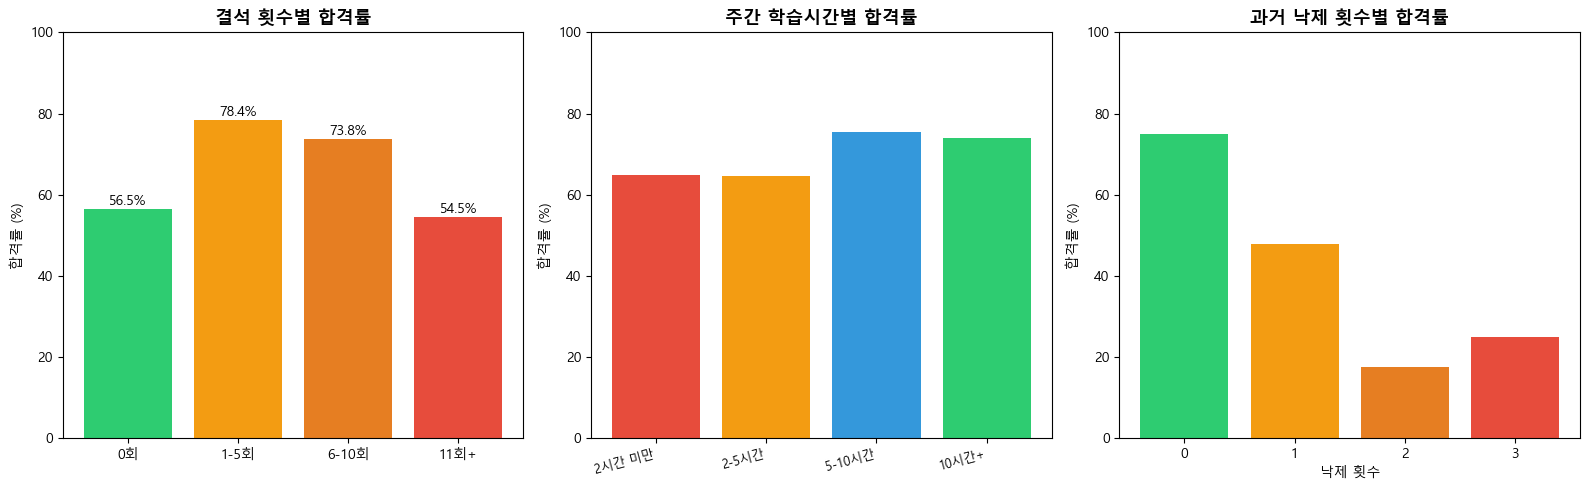

In [6]:
# 교육 현장 핵심 변수 분석: 결석, 학습시간, 과거 낙제 경험
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 결석 횟수별 합격률
df['absences_group'] = pd.cut(df['absences'], bins=[-1, 0, 5, 10, 100],
                               labels=['0회', '1-5회', '6-10회', '11회+'])
absence_pass = df.groupby('absences_group')['pass'].mean() * 100
bars = axes[0].bar(absence_pass.index, absence_pass.values,
                   color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'])
axes[0].set_title('결석 횟수별 합격률', fontsize=13, fontweight='bold')
axes[0].set_ylabel('합격률 (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, absence_pass.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=10)

# 주간 학습시간별 합격률
study_labels = {1: '2시간 미만', 2: '2-5시간', 3: '5-10시간', 4: '10시간+'}
df['studytime_label'] = df['studytime'].map(study_labels)
study_pass = df.groupby('studytime')['pass'].mean() * 100
study_pass.index = [study_labels[i] for i in study_pass.index]
axes[1].bar(range(len(study_pass)), study_pass.values,
            color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'])
axes[1].set_xticks(range(len(study_pass)))
axes[1].set_xticklabels(study_pass.index, rotation=15, ha='right', fontsize=9)
axes[1].set_title('주간 학습시간별 합격률', fontsize=13, fontweight='bold')
axes[1].set_ylabel('합격률 (%)')
axes[1].set_ylim(0, 100)

# 과거 낙제 경험별 합격률
fail_pass = df.groupby('failures')['pass'].mean() * 100
axes[2].bar(fail_pass.index.astype(str), fail_pass.values,
            color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'])
axes[2].set_title('과거 낙제 횟수별 합격률', fontsize=13, fontweight='bold')
axes[2].set_xlabel('낙제 횟수')
axes[2].set_ylabel('합격률 (%)')
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../data/key_factors.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. 데이터 전처리

In [7]:
# 범주형 변수 인코딩
df_model = df.copy()

# 파생 변수 제거 (분석용으로 만든 것)
df_model = df_model.drop(columns=['absences_group', 'studytime_label'], errors='ignore')

# 범주형 변수 Label Encoding
cat_cols = df_model.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# 타겟: G3 제거, G1/G2 포함 (실제 교육 현장에서 중간 성적은 알 수 있음)
X = df_model.drop(columns=['G3', 'pass'])
y = df_model['pass']

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'학습 데이터: {X_train.shape[0]}명, 테스트 데이터: {X_test.shape[0]}명')
print(f'특성 수: {X_train.shape[1]}개')

학습 데이터: 316명, 테스트 데이터: 79명
특성 수: 32개


## 3. 모델 학습 및 비교

In [8]:
# 3개 모델 학습 및 비교
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    cv_scores = cross_val_score(model,
                                X_train_scaled if name == 'Logistic Regression' else X_train,
                                y_train, cv=5, scoring='accuracy')
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': (y_pred == y_test).mean(),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    print(f'{name}: 정확도={results[name]["accuracy"]:.3f}, ROC-AUC={results[name]["roc_auc"]:.3f}, CV={cv_scores.mean():.3f}(±{cv_scores.std():.3f})')

Logistic Regression: 정확도=0.861, ROC-AUC=0.943, CV=0.873(±0.039)
Random Forest: 정확도=0.873, ROC-AUC=0.951, CV=0.933(±0.041)
XGBoost: 정확도=0.861, ROC-AUC=0.924, CV=0.902(±0.034)


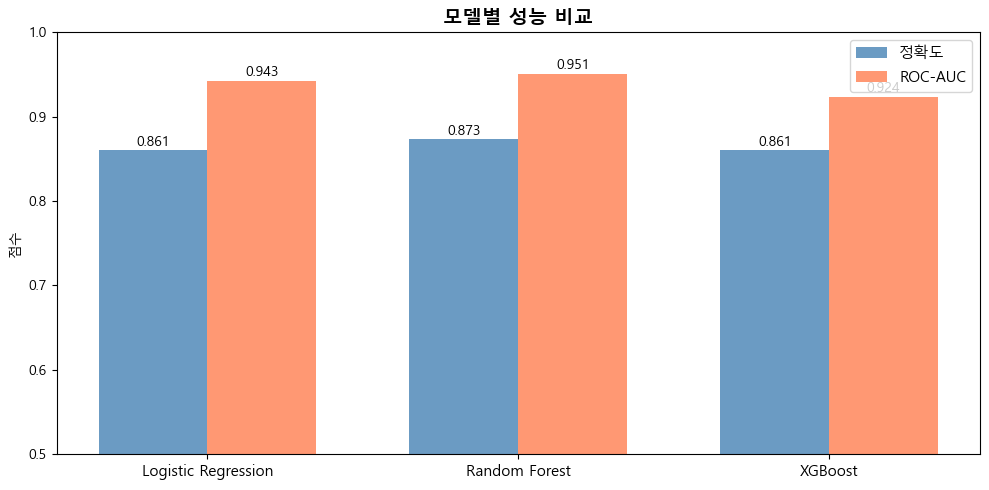

In [9]:
# 모델 성능 비교 시각화
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
roc_aucs = [results[m]['roc_auc'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='정확도', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, roc_aucs, width, label='ROC-AUC', color='coral', alpha=0.8)

ax.set_title('모델별 성능 비교', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=11)
ax.set_ylabel('점수')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 핵심 인사이트: 성취도에 영향을 주는 변수 Top 10

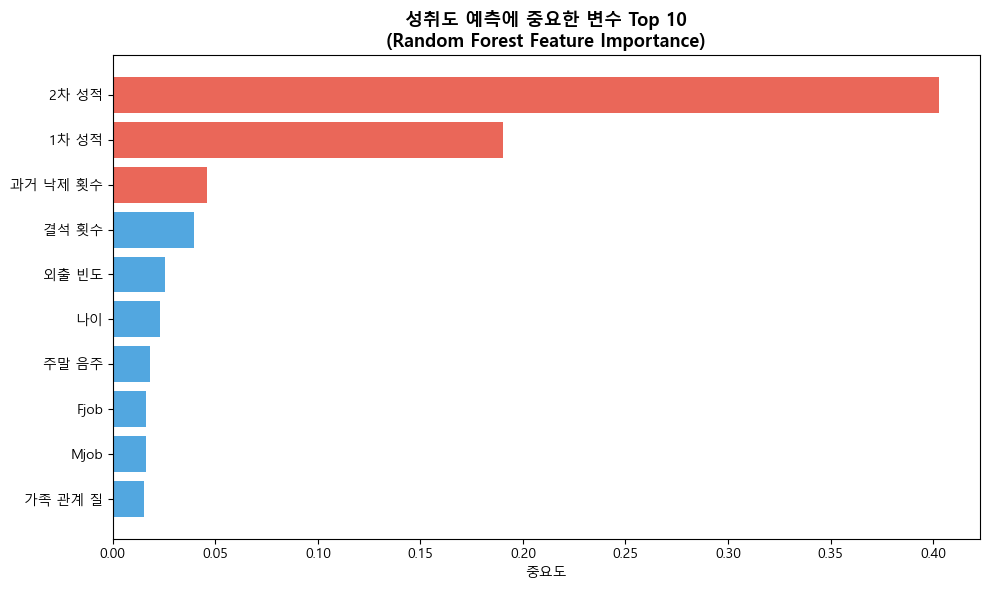


[교육 현장 시사점]
1. 1, 2차 성적이 최종 성적의 강력한 예측 변수 → 중간 점검이 핵심
2. 과거 낙제 경험이 있는 학생은 조기 개입 우선 대상
3. 결석 횟수 증가 시 즉각 상담 필요


In [10]:
# Random Forest Feature Importance
rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

# 변수명 한국어 매핑
feature_labels = {
    'G2': '2차 성적', 'G1': '1차 성적', 'failures': '과거 낙제 횟수',
    'absences': '결석 횟수', 'age': '나이', 'studytime': '주간 학습시간',
    'Medu': '어머니 학력', 'Fedu': '아버지 학력', 'goout': '외출 빈도',
    'freetime': '방과후 여가시간', 'health': '건강 상태', 'famrel': '가족 관계 질',
    'Dalc': '주중 음주', 'Walc': '주말 음주', 'traveltime': '통학 시간'
}
feature_importance['label'] = feature_importance['feature'].map(
    lambda x: feature_labels.get(x, x)
)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(feature_importance))]
bars = plt.barh(feature_importance['label'][::-1],
                feature_importance['importance'][::-1],
                color=colors[::-1], alpha=0.85)
plt.title('성취도 예측에 중요한 변수 Top 10\n(Random Forest Feature Importance)',
          fontsize=13, fontweight='bold')
plt.xlabel('중요도')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n[교육 현장 시사점]')
print('1. 1, 2차 성적이 최종 성적의 강력한 예측 변수 → 중간 점검이 핵심')
print('2. 과거 낙제 경험이 있는 학생은 조기 개입 우선 대상')
print('3. 결석 횟수 증가 시 즉각 상담 필요')

## 5. 결론 및 교육 현장 적용 방안

In [11]:
best_model_name = max(results, key=lambda m: results[m]['roc_auc'])
best = results[best_model_name]

print('=' * 50)
print(f'최고 성능 모델: {best_model_name}')
print(f'정확도: {best["accuracy"]:.3f} | ROC-AUC: {best["roc_auc"]:.3f}')
print('=' * 50)
print()
print('[분류 리포트]')
print(classification_report(y_test, best['y_pred'], target_names=['불합격', '합격']))
print()
print('[교육 현장 적용 방안]')
print('- 1차 시험 직후 모델 적용 → 위험군 학생 조기 식별')
print('- 결석 5회 이상 학생 자동 알림 시스템 연계')
print('- 과거 낙제 경험 학생 별도 보충 프로그램 설계')
print()
print('[향후 연구 방향]')
print('- 코딩 교육 수강생 실제 데이터 수집 및 적용')
print('- 학습 로그 시계열 분석으로 이탈 예측 고도화')
print('- 개인별 맞춤 커리큘럼 추천 알고리즘 개발')

최고 성능 모델: Random Forest
정확도: 0.873 | ROC-AUC: 0.951

[분류 리포트]
              precision    recall  f1-score   support

         불합격       0.75      0.92      0.83        26
          합격       0.96      0.85      0.90        53

    accuracy                           0.87        79
   macro avg       0.85      0.89      0.86        79
weighted avg       0.89      0.87      0.88        79


[교육 현장 적용 방안]
- 1차 시험 직후 모델 적용 → 위험군 학생 조기 식별
- 결석 5회 이상 학생 자동 알림 시스템 연계
- 과거 낙제 경험 학생 별도 보충 프로그램 설계

[향후 연구 방향]
- 코딩 교육 수강생 실제 데이터 수집 및 적용
- 학습 로그 시계열 분석으로 이탈 예측 고도화
- 개인별 맞춤 커리큘럼 추천 알고리즘 개발
